# KMeans Clustering -- Manual Implementation

This notebook walks through KMeans **step by step**, showing the math and then the code for each operation.

**Algorithm overview:**
1. **Initialise** -- randomly pick K points as initial centroids
2. **Assign** -- for each point, compute distance to every centroid, assign to nearest
3. **Update** -- recalculate each centroid as the mean of its assigned points
4. **Repeat** steps 2-3 until centroids stop moving (convergence)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

# GDV_Q is a list of 7 hex colour codes from the GeoDataViz qualitative palette,
# chosen for accessibility and visual distinction between categories.
GDV_Q = ["#FF1F5B", "#00CD6C", "#009ADE", "#AF58BA", "#FFC61E", "#F28522", "#A0B1BA"]
# rcParams["axes.prop_cycle"] sets the default colour cycle for all matplotlib plots,
# so each new line/scatter series automatically uses the next GDV colour.
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=GDV_Q)

---
## Step 0: Create Data

We use 6 simple 2D points so we can trace every calculation by hand.

In [ ]:
X = np.array([
    [1.0, 2.0],
    [1.5, 1.8],
    [5.0, 8.0],
    [8.0, 8.0],
    [1.0, 0.6],
    [9.0, 11.0]
])
print("Shape:", X.shape, " -> 6 points, 2 features")

In [ ]:
# Visualise the raw data
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0], X[:, 1], s=80, c="#A0B1BA", edgecolors="white", zorder=3)
for i, p in enumerate(X):
    ax.annotate(f"x{i+1}", (p[0]+0.2, p[1]+0.3), fontsize=9)
ax.set_title("Raw Data")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Choose K and pick initial centroids
K = 2
# Python uses 0-based indexing, so X[1] is the 2nd point (x2) and X[2] is the 3rd point (x3).
centroids = np.array([X[1], X[2]])  # x2 and x3

print(f"K = {K}")
print(f"C1 = {centroids[0]}")
print(f"C2 = {centroids[1]}")

In [ ]:
# Plot data with initial centroids marked
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0], X[:, 1], s=80, c="#A0B1BA", edgecolors="white", zorder=3)
for i, p in enumerate(X):
    ax.annotate(f"x{i+1}", (p[0]+0.2, p[1]+0.3), fontsize=9)
ax.scatter(centroids[:, 0], centroids[:, 1], c=[GDV_Q[0], GDV_Q[1]],
           marker="D", s=120, edgecolors="white", linewidths=1.5, zorder=4)
ax.annotate("C1", (centroids[0,0]+0.3, centroids[0,1]-0.5), fontsize=10, fontweight="bold", color=GDV_Q[0])
ax.annotate("C2", (centroids[1,0]+0.3, centroids[1,1]-0.5), fontsize=10, fontweight="bold", color=GDV_Q[1])
ax.set_title("Step 1: Initial Centroids")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Compute distance from every point to every centroid
# zeros((len(X), K)) creates a 6x2 matrix of zeros -- one row per point, one column per centroid.
dists = np.zeros((len(X), K))
for k in range(K):
    # X - centroids[k] uses broadcasting: NumPy subtracts the single centroid from EVERY row of X at once.
    # axis=1 means "compute the norm across columns (features)", giving one distance per point.
    dists[:, k] = np.linalg.norm(X - centroids[k], axis=1)

print("Distance matrix (each row = a point, each col = a centroid):")
print(dists.round(3))

In [ ]:
# Print the full distance table with assignments
print(f"{'Point':<12} | {'d(C1)':>8} | {'d(C2)':>8} | {'Assign':>8}")
print("-" * 45)
for i in range(len(X)):
    winner = "C1" if labels[i] == 0 else "C2"
    print(f"x{i+1} {str(X[i]):<8} | {dists[i,0]:>8.3f} | {dists[i,1]:>8.3f} | {winner:>8}")

In [ ]:
# Assign each point to the nearest centroid.
# argmin returns the column INDEX of the smallest value in each row.
# axis=1 means "look across columns (centroids) for each row (point)".
# e.g. if dists[0] = [0.539, 7.211], argmin returns 0 (column 0 = C1).
labels = np.argmin(dists, axis=1)
print("labels =", labels, "  (0 = C1, 1 = C2)")

In [ ]:
# Save old centroids for comparison.
# .copy() creates an independent copy of the array. Without it, old_centroids
# and centroids would point to the SAME data in memory, so changing one would
# change the other -- and we would lose the original values.
old_centroids = centroids.copy()

In [ ]:
# How far did each centroid move?
for k in range(K):
    # np.linalg.norm computes the Euclidean distance between the old and new centroid positions.
    moved = np.linalg.norm(new_centroids[k] - old_centroids[k])
    print(f"C{k+1}: {old_centroids[k]} -> {new_centroids[k]}  (moved {moved:.3f})")

# Update centroids for next iteration
centroids = new_centroids

In [ ]:
# Compute new centroids as the mean of each cluster.
# zeros_like creates a zero array with the same shape and dtype as centroids (K x 2).
new_centroids = np.zeros_like(centroids)
for k in range(K):
    # Boolean indexing: labels == k produces a True/False array, and X[labels == k]
    # selects only the rows of X where the condition is True (i.e. points in cluster k).
    members = X[labels == k]
    # mean(axis=0) averages down each column (feature), giving a single [x, y] centroid.
    new_centroids[k] = members.mean(axis=0)
    print(f"Cluster {k+1} members: {members.tolist()}")
    print(f"  Mean = ({' + '.join([str(p[0]) for p in members])}) / {len(members)},"
          f" ({' + '.join([str(p[1]) for p in members])}) / {len(members)}")
    print(f"  C{k+1}_new = {new_centroids[k]}")
    print()

In [ ]:
# Repeat the distance computation, now using the UPDATED centroids from iteration 1.
dists2 = np.zeros((len(X), K))
for k in range(K):
    dists2[:, k] = np.linalg.norm(X - centroids[k], axis=1)

In [ ]:
# Compare with previous assignment -- did any point change?
print(f"{'Point':<12} | {'d(C1)':>8} | {'d(C2)':>8} | {'Assign':>8} | {'Changed?':>8}")
print("-" * 58)
for i in range(len(X)):
    winner = "C1" if labels2[i] == 0 else "C2"
    changed = "YES" if labels2[i] != labels[i] else ""
    print(f"x{i+1} {str(X[i]):<8} | {dists2[i,0]:>8.3f} | {dists2[i,1]:>8.3f} | {winner:>8} | {changed:>8}")

print(f"\nPoints that changed cluster: {np.sum(labels2 != labels)}")

In [ ]:
# Recompute centroids
new_centroids2 = np.zeros_like(centroids)
for k in range(K):
    members = X[labels2 == k]
    new_centroids2[k] = members.mean(axis=0)

print(f"Old centroids: {centroids}")
print(f"New centroids: {new_centroids2}")

In [ ]:
# Check convergence: are old and new centroids the same?
converged = np.allclose(new_centroids2, centroids)
print(f"np.allclose(old, new) = {converged}")
print("Centroids did not move. Algorithm terminates.")

In [6]:
# Compute distances from every point to every centroid
dists = np.zeros((len(X), K))
for k in range(K):
    dists[:, k] = np.linalg.norm(X - centroids[k], axis=1)

# Assign to nearest centroid
labels = np.argmin(dists, axis=1)

# Print distance table
print(f"{'Point':<12} | {'d(C1)':>8} | {'d(C2)':>8} | {'Assign':>8}")
print("-" * 45)
for i in range(len(X)):
    winner = "C1" if labels[i] == 0 else "C2"
    print(f"x{i+1} {str(X[i]):<8} | {dists[i,0]:>8.3f} | {dists[i,1]:>8.3f} | {winner:>8}")

Point        |    d(C1) |    d(C2) |   Assign
---------------------------------------------
x1 [1. 2.]  |    0.539 |    7.211 |       C1
x2 [1.5 1.8] |    0.000 |    7.120 |       C1
x3 [5. 8.]  |    7.120 |    0.000 |       C2
x4 [8. 8.]  |    8.983 |    3.000 |       C2
x5 [1.  0.6] |    1.300 |    8.412 |       C1
x6 [ 9. 11.] |   11.870 |    5.000 |       C2


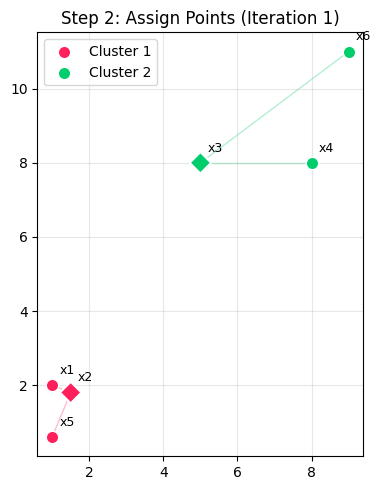

In [7]:
# Visualise assignments
fig, ax = plt.subplots(figsize=(5, 5))
for k in range(K):
    mask = labels == k
    ax.scatter(X[mask, 0], X[mask, 1], s=80, c=GDV_Q[k], edgecolors="white", zorder=3,
              label=f"Cluster {k+1}")
    # Draw lines from points to centroid
    for p in X[mask]:
        ax.plot([p[0], centroids[k, 0]], [p[1], centroids[k, 1]],
               c=GDV_Q[k], alpha=0.3, linewidth=1, zorder=1)
for i, p in enumerate(X):
    ax.annotate(f"x{i+1}", (p[0]+0.2, p[1]+0.3), fontsize=9)
ax.scatter(centroids[:, 0], centroids[:, 1], c=[GDV_Q[0], GDV_Q[1]],
           marker="D", s=120, edgecolors="white", linewidths=1.5, zorder=4)
ax.set_title("Step 2: Assign Points (Iteration 1)")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 3: Update Centroids (Iteration 1)

New centroid = mean of all points assigned to that cluster.

$$C_k^{\text{new}} = \frac{1}{|S_k|} \sum_{x_i \in S_k} x_i$$

**Cluster 1** contains $x_1=(1,2)$, $x_2=(1.5,1.8)$, $x_5=(1,0.6)$:

$$C_1^{\text{new}} = \left(\frac{1+1.5+1}{3},\; \frac{2+1.8+0.6}{3}\right) = \left(\frac{3.5}{3},\; \frac{4.4}{3}\right) = (1.167,\; 1.467)$$

**Cluster 2** contains $x_3=(5,8)$, $x_4=(8,8)$, $x_6=(9,11)$:

$$C_2^{\text{new}} = \left(\frac{5+8+9}{3},\; \frac{8+8+11}{3}\right) = \left(\frac{22}{3},\; \frac{27}{3}\right) = (7.333,\; 9.000)$$

In [8]:
old_centroids = centroids.copy()

new_centroids = np.zeros_like(centroids)
for k in range(K):
    members = X[labels == k]
    new_centroids[k] = members.mean(axis=0)
    print(f"Cluster {k+1} members: {members.tolist()}")
    print(f"  Mean = ({' + '.join([str(p[0]) for p in members])}) / {len(members)},"
          f" ({' + '.join([str(p[1]) for p in members])}) / {len(members)}")
    print(f"  C{k+1}_new = {new_centroids[k]}")
    moved = np.linalg.norm(new_centroids[k] - old_centroids[k])
    print(f"  Moved: {moved:.3f}\n")

centroids = new_centroids

Cluster 1 members: [[1.0, 2.0], [1.5, 1.8], [1.0, 0.6]]
  Mean = (1.0 + 1.5 + 1.0) / 3, (2.0 + 1.8 + 0.6) / 3
  C1_new = [1.16666667 1.46666667]
  Moved: 0.471

Cluster 2 members: [[5.0, 8.0], [8.0, 8.0], [9.0, 11.0]]
  Mean = (5.0 + 8.0 + 9.0) / 3, (8.0 + 8.0 + 11.0) / 3
  C2_new = [7.33333333 9.        ]
  Moved: 2.539



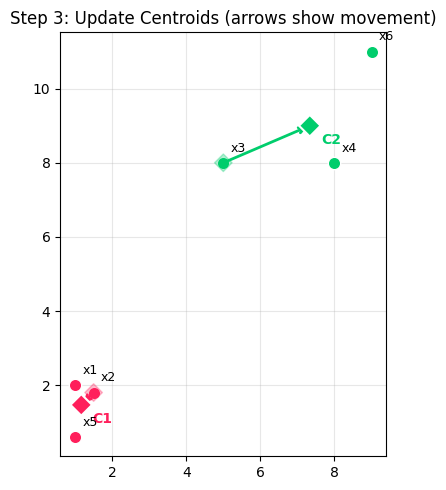

In [9]:
# Visualise centroid movement
fig, ax = plt.subplots(figsize=(5, 5))
for k in range(K):
    mask = labels == k
    ax.scatter(X[mask, 0], X[mask, 1], s=80, c=GDV_Q[k], edgecolors="white", zorder=3)
# Old centroids (faded)
ax.scatter(old_centroids[:, 0], old_centroids[:, 1], c=[GDV_Q[0], GDV_Q[1]],
           marker="D", s=80, alpha=0.3, zorder=4)
# New centroids
ax.scatter(centroids[:, 0], centroids[:, 1], c=[GDV_Q[0], GDV_Q[1]],
           marker="D", s=120, edgecolors="white", linewidths=1.5, zorder=5)
# Arrows showing movement
for k in range(K):
    ax.annotate("", xy=centroids[k], xytext=old_centroids[k],
               arrowprops=dict(arrowstyle="->", color=GDV_Q[k], lw=2))
    ax.annotate(f"C{k+1}", (centroids[k,0]+0.3, centroids[k,1]-0.5),
               fontsize=10, fontweight="bold", color=GDV_Q[k])
for i, p in enumerate(X):
    ax.annotate(f"x{i+1}", (p[0]+0.2, p[1]+0.3), fontsize=9)
ax.set_title("Step 3: Update Centroids (arrows show movement)")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 4: Assign Points (Iteration 2)

Repeat the assignment step with the new centroids:

$$C_1 = (1.167,\; 1.467), \quad C_2 = (7.333,\; 9.000)$$

**Hand calculation for $x_1 = (1, 2)$:**

$$d(x_1, C_1) = \sqrt{(1-1.167)^2 + (2-1.467)^2} = \sqrt{0.028 + 0.284} = 0.559$$

$$d(x_1, C_2) = \sqrt{(1-7.333)^2 + (2-9)^2} = \sqrt{40.11 + 49} = 9.44$$

Still assigned to **C1**. Let's check all points:

In [ ]:
# Assign with new centroids
dists2 = np.zeros((len(X), K))
for k in range(K):
    dists2[:, k] = np.linalg.norm(X - centroids[k], axis=1)

# Re-assign every point to the nearest centroid using the updated centroid positions.
labels2 = np.argmin(dists2, axis=1)

print(f"{'Point':<12} | {'d(C1)':>8} | {'d(C2)':>8} | {'Assign':>8} | {'Changed?':>8}")
print("-" * 58)
for i in range(len(X)):
    winner = "C1" if labels2[i] == 0 else "C2"
    changed = "YES" if labels2[i] != labels[i] else ""
    print(f"x{i+1} {str(X[i]):<8} | {dists2[i,0]:>8.3f} | {dists2[i,1]:>8.3f} | {winner:>8} | {changed:>8}")

# np.sum on a boolean array counts the number of True values (True = 1, False = 0).
print(f"\nPoints that changed cluster: {np.sum(labels2 != labels)}")

---
## Step 5: Update Centroids (Iteration 2)

Since assignments haven't changed, the new centroids will be the same as before.

$$C_1^{\text{new}} = C_1^{\text{old}} = (1.167,\; 1.467)$$
$$C_2^{\text{new}} = C_2^{\text{old}} = (7.333,\; 9.000)$$

Centroids did not move. **Converged.**

In [ ]:
old_centroids2 = centroids.copy()
new_centroids2 = np.zeros_like(centroids)
for k in range(K):
    members = X[labels2 == k]
    new_centroids2[k] = members.mean(axis=0)

# np.allclose checks whether two arrays are element-wise equal within a tiny
# tolerance (default 1e-8). This handles floating-point rounding so we don't
# need exact equality.
converged = np.allclose(new_centroids2, centroids)
print(f"Old centroids: {centroids}")
print(f"New centroids: {new_centroids2}")
print(f"\nConverged: {converged}")
print("Centroids did not move. Algorithm terminates.")

---
## Final Result

The algorithm converged after **2 iterations**.

| Cluster | Centroid | Members |
|---------|----------|--------|
| C1 | (1.167, 1.467) | x1, x2, x5 |
| C2 | (7.333, 9.000) | x3, x4, x6 |

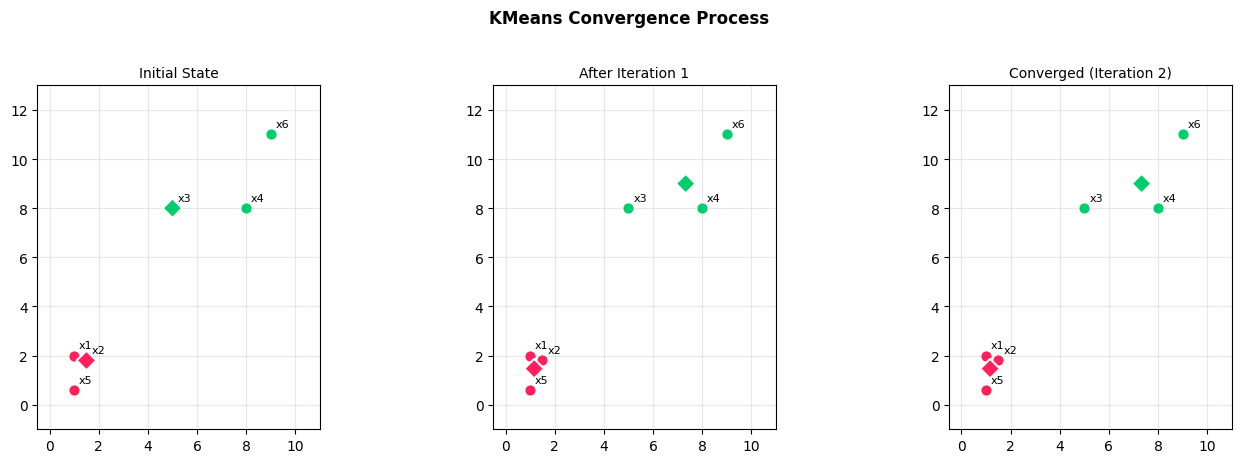

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

titles = ["Initial State", "After Iteration 1", "Converged (Iteration 2)"]
all_centroids = [
    np.array([X[1], X[2]]),     # initial
    centroids,                   # after iter 1
    new_centroids2               # final
]

for idx, (ax, title, cents) in enumerate(zip(axes, titles, all_centroids)):
    # Recompute labels for this centroid set
    d = np.zeros((len(X), K))
    for k in range(K):
        d[:, k] = np.linalg.norm(X - cents[k], axis=1)
    lbl = np.argmin(d, axis=1)
    
    for k in range(K):
        mask = lbl == k
        ax.scatter(X[mask, 0], X[mask, 1], s=70, c=GDV_Q[k], edgecolors="white", zorder=3)
    ax.scatter(cents[:, 0], cents[:, 1], c=[GDV_Q[0], GDV_Q[1]],
              marker="D", s=100, edgecolors="white", linewidths=1.5, zorder=4)
    for i, p in enumerate(X):
        ax.annotate(f"x{i+1}", (p[0]+0.2, p[1]+0.3), fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.5, 11)
    ax.set_ylim(-1, 13)

plt.suptitle("KMeans Convergence Process", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## Verify with sklearn

In [ ]:
from sklearn.cluster import KMeans

# init=... tells sklearn to use OUR initial centroids instead of random ones.
# n_init=1 means run the algorithm once (sklearn defaults to 10 random restarts).
km = KMeans(n_clusters=2, init=np.array([X[1], X[2]]), n_init=1, random_state=0)
km.fit(X)

# Attributes ending with an underscore (like cluster_centers_) are "computed attributes"
# -- they only exist after calling .fit() and hold the results learned from the data.
print("sklearn centroids:", km.cluster_centers_)
print("Our centroids:    ", new_centroids2)
print("\nsklearn labels:", km.labels_)
print("Our labels:     ", labels2)
print("\nMatch:", np.allclose(km.cluster_centers_, new_centroids2))